In [1]:
!python --version

Python 3.11.15


In [2]:
import sys 
print(sys.version)

3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]


In [3]:
!pip install --upgrade pip setuptools wheel
!pip install pygame

In [4]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
C:\Users\Abhishek\anaconda3\envs\pongrl\python.exe

Python version:
3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]


In [5]:
import sys
import pygame
import numpy as np
import random
import math
print("Python:", sys.executable)
print("Pygame:", pygame.version.ver)
print("NumPy:", np.__version__)

pygame 2.6.1 (SDL 2.28.4, Python 3.11.15)
Hello from the pygame community. https://www.pygame.org/contribute.html
Python: C:\Users\Abhishek\anaconda3\envs\pongrl\python.exe
Pygame: 2.6.1
NumPy: 2.4.6


In [6]:
# ============================================================
# PONG CONFIGURATION
# ============================================================

WIDTH = 800
HEIGHT = 500
FPS = 60

PADDLE_WIDTH = 15
PADDLE_HEIGHT = 100
PADDLE_SPEED = 7

BALL_SIZE = 12
BALL_SPEED = 5

# Basic colors
BLACK = (0, 0, 0)
WHITE = (255, 255, 255)

# Paddle positions
LEFT_PADDLE_X = 30
RIGHT_PADDLE_X = WIDTH - 45

# Ball collision targets
LEFT_TARGET_X = LEFT_PADDLE_X + PADDLE_WIDTH
RIGHT_TARGET_X = RIGHT_PADDLE_X - BALL_SIZE

print("Pong configuration loaded")
print(f"Board: {WIDTH} x {HEIGHT}")
print(f"Left target: {LEFT_TARGET_X}")
print(f"Right target: {RIGHT_TARGET_X}")

Pong configuration loaded
Board: 800 x 500
Left target: 45
Right target: 743


In [7]:
pygame.init()

screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Pong RL")

clock = pygame.time.Clock()

print("Pygame initialized successfully")

Pygame initialized successfully


In [8]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "-m", "pip", "show", "pygame"],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

Name: pygame
Version: 2.6.1
Summary: Python Game Development
Home-page: https://www.pygame.org
Author: A community project.
Author-email: pygame@pygame.org
License: LGPL
Location: C:\Users\Abhishek\anaconda3\envs\pongrl\Lib\site-packages
Requires: 
Required-by: 




In [9]:
# ============================================================
# GLASSMORPHIC PONG THEME
# ============================================================

# Color-wheel inspired palette
LEFT_COLOR = (0, 220, 255)        # Cyan
RIGHT_COLOR = (255, 70, 180)      # Magenta
BALL_COLOR = (255, 255, 255)

GLASS_FILL = (255, 255, 255, 22)
GLASS_BORDER = (255, 255, 255, 70)

TEXT_COLOR = (235, 240, 255)
MUTED_COLOR = (150, 160, 180)

CENTER_LINE_COLOR = (255, 255, 255, 55)

BACKGROUND_IMAGE = None


def load_background(path):
    global BACKGROUND_IMAGE

    image = pygame.image.load(path).convert()
    BACKGROUND_IMAGE = pygame.transform.smoothscale(
        image,
        (WIDTH, HEIGHT)
    )

    print("Background loaded:", path)


def draw_glass_board(screen):

    # Main translucent glass panel
    glass = pygame.Surface(
        (WIDTH, HEIGHT),
        pygame.SRCALPHA
    )

    pygame.draw.rect(
        glass,
        GLASS_FILL,
        pygame.Rect(
            10,
            10,
            WIDTH - 20,
            HEIGHT - 20
        ),
        border_radius=25
    )

    pygame.draw.rect(
        glass,
        GLASS_BORDER,
        pygame.Rect(
            10,
            10,
            WIDTH - 20,
            HEIGHT - 20
        ),
        width=2,
        border_radius=25
    )

    screen.blit(glass, (0, 0))


def draw_glow(screen, x, y, color, radius=35):

    glow = pygame.Surface(
        (radius * 2, radius * 2),
        pygame.SRCALPHA
    )

    # Draw several transparent circles.
    # No special Pygame blend flags required.
    for r in range(radius, 2, -3):

        alpha = int(
            45 * (1 - r / radius)
        )

        pygame.draw.circle(
            glow,
            (*color, alpha),
            (radius, radius),
            r
        )

    screen.blit(
        glow,
        (
            int(x - radius),
            int(y - radius)
        )
    )


def draw_themed_paddle(screen, x, y, color):

    rect = pygame.Rect(
        x,
        int(y),
        PADDLE_WIDTH,
        PADDLE_HEIGHT
    )

    # Glow behind paddle
    draw_glow(
        screen,
        rect.centerx,
        rect.centery,
        color,
        45
    )

    # Paddle body
    paddle = pygame.Surface(
        rect.size,
        pygame.SRCALPHA
    )

    pygame.draw.rect(
        paddle,
        (*color, 220),
        paddle.get_rect(),
        border_radius=8
    )

    # Glass highlight
    pygame.draw.rect(
        paddle,
        (255, 255, 255, 70),
        pygame.Rect(
            2,
            2,
            PADDLE_WIDTH - 4,
            PADDLE_HEIGHT - 4
        ),
        width=1,
        border_radius=7
    )

    screen.blit(
        paddle,
        rect.topleft
    )


def draw_themed_ball(screen, x, y):

    cx = int(x + BALL_SIZE / 2)
    cy = int(y + BALL_SIZE / 2)

    # Glow
    draw_glow(
        screen,
        cx,
        cy,
        BALL_COLOR,
        30
    )

    pygame.draw.circle(
        screen,
        BALL_COLOR,
        (cx, cy),
        BALL_SIZE // 2
    )


def draw_themed_center_line(screen):

    x = WIDTH // 2

    for y in range(35, HEIGHT - 35, 24):

        pygame.draw.rect(
            screen,
            CENTER_LINE_COLOR,
            pygame.Rect(
                x - 1,
                y,
                2,
                11
            ),
            border_radius=2
        )


def draw_themed_score(
    screen,
    left_score,
    right_score
):

    font = pygame.font.SysFont(
        "segoeui",
        42,
        bold=True
    )

    left = font.render(
        str(left_score),
        True,
        LEFT_COLOR
    )

    right = font.render(
        str(right_score),
        True,
        RIGHT_COLOR
    )

    screen.blit(
        left,
        (
            WIDTH // 2 - 80,
            22
        )
    )

    screen.blit(
        right,
        (
            WIDTH // 2 + 55,
            22
        )
    )

In [10]:
def draw_themed_scene(
    screen,
    ball_x,
    ball_y,
    left_x,
    left_y,
    right_x,
    right_y,
    left_score,
    right_score
):

    # =================================
    # BACKGROUND
    # =================================

    if BACKGROUND_IMAGE is not None:

        screen.blit(
            BACKGROUND_IMAGE,
            (0, 0)
        )

        # Dark glass overlay
        overlay = pygame.Surface(
            (WIDTH, HEIGHT),
            pygame.SRCALPHA
        )

        overlay.fill(
            (5, 8, 20, 145)
        )

        screen.blit(
            overlay,
            (0, 0)
        )

    else:

        screen.fill(
            (8, 10, 20)
        )

    # =================================
    # GLASS BOARD
    # =================================

    draw_glass_board(screen)

    # =================================
    # CENTER LINE
    # =================================

    draw_themed_center_line(screen)

    # =================================
    # LEFT PADDLE
    # =================================

    draw_themed_paddle(
        screen,
        left_x,
        left_y,
        LEFT_COLOR
    )

    # =================================
    # RIGHT PADDLE
    # =================================

    draw_themed_paddle(
        screen,
        right_x,
        right_y,
        RIGHT_COLOR
    )

    # =================================
    # BALL
    # =================================

    draw_themed_ball(
        screen,
        ball_x,
        ball_y
    )

    # =================================
    # SCORE
    # =================================

    draw_themed_score(
        screen,
        left_score,
        right_score
    )

In [11]:
load_background("a14f73fa325c54e372d60790441d7894.jpg")

Background loaded: a14f73fa325c54e372d60790441d7894.jpg


In [12]:
def reset_ball(direction):
    x = random.uniform(
        WIDTH * 0.35,
        WIDTH * 0.65
    )

    y = random.uniform(
        HEIGHT * 0.20,
        HEIGHT * 0.80
    )

    angle = math.radians(
        random.uniform(15, 45)
    )

    if random.choice([True, False]):
        angle = -angle

    vx = BALL_SPEED * direction * math.cos(angle)
    vy = BALL_SPEED * math.sin(angle)

    return x, y, vx, vy


# Test it immediately
test = reset_ball(1)

print("Reset test:")
print("Position:", test[0], test[1])
print("Velocity:", test[2], test[3])

Reset test:
Position: 453.0086181235385 197.00209875805146
Velocity: 4.777495618475693 -1.4749696998398154


In [13]:
import csv
from datetime import datetime


class PongLogger:

    def __init__(self):
        self.data = []
        self.rally_id = 0
        self.frame = 0

    def new_rally(self):
        self.rally_id += 1

    def record(
        self,
        event,
        ball_x,
        ball_y,
        ball_vx,
        ball_vy,
        left_y,
        right_y,
        hit_position=None,
        angle=None,
        scorer=None
    ):

        self.frame += 1

        self.data.append({
            "timestamp": datetime.now().isoformat(),
            "rally": self.rally_id,
            "frame": self.frame,

            "event": event,

            "ball_x": round(ball_x, 3),
            "ball_y": round(ball_y, 3),

            "ball_vx": round(ball_vx, 3),
            "ball_vy": round(ball_vy, 3),

            "left_paddle_y": round(left_y, 3),
            "right_paddle_y": round(right_y, 3),

            "hit_position": (
                round(hit_position, 3)
                if hit_position is not None
                else None
            ),

            "angle": (
                round(angle, 3)
                if angle is not None
                else None
            ),

            "scorer": scorer
        })

    def save_csv(self, filename="pong_data.csv"):

        if not self.data:
            print("No data to save.")
            return

        with open(filename, "w", newline="") as file:

            writer = csv.DictWriter(
                file,
                fieldnames=self.data[0].keys()
            )

            writer.writeheader()
            writer.writerows(self.data)

        print(f"Saved {len(self.data)} records to {filename}")

In [14]:
def move_paddle_to_target(
    paddle_y,
    target_y,
    paddle_speed,
    tolerance=10
):
    """
    Move a paddle toward target_y.

    tolerance prevents tiny left/right oscillations.
    """

    paddle_center = (
        paddle_y + PADDLE_HEIGHT / 2
    )

    error = target_y - paddle_center

    # Already close enough → don't move
    if abs(error) <= tolerance:
        return paddle_y

    if error > 0:
        paddle_y += paddle_speed
    else:
        paddle_y -= paddle_speed

    # Keep paddle inside the screen
    paddle_y = max(
        0,
        min(
            HEIGHT - PADDLE_HEIGHT,
            paddle_y
        )
    )

    return paddle_y

In [15]:
def run_pong():

    pygame.init()

    screen = pygame.display.set_mode(
        (WIDTH, HEIGHT)
    )

    pygame.display.set_caption(
        "Pong - Geometric AI"
    )

    clock = pygame.time.Clock()

    # -----------------------------
    # Paddle positions
    # -----------------------------

    left_x = 15
    right_x = WIDTH - 30

    left_y = (
        HEIGHT - PADDLE_HEIGHT
    ) / 2

    right_y = (
        HEIGHT - PADDLE_HEIGHT
    ) / 2

    # -----------------------------
    # Ball
    # -----------------------------

    ball_x, ball_y, ball_vx, ball_vy = (
        reset_ball(direction=1)
    )

    # -----------------------------
    # Score
    # -----------------------------

    left_score = 0
    right_score = 0

    font = pygame.font.Font(
        None,
        48
    )

    # -----------------------------
    # Logger
    # -----------------------------

    logger = PongLogger()

    logger.new_rally()

    running = True

    while running:

        # =================================
        # EVENTS
        # =================================

        for event in pygame.event.get():

            if event.type == pygame.QUIT:
                running = False

        # =================================
        # LEFT PADDLE - HUMAN
        # =================================

        keys = pygame.key.get_pressed()

        if keys[pygame.K_w]:
            left_y -= PADDLE_SPEED

        if keys[pygame.K_s]:
            left_y += PADDLE_SPEED

        # Keep paddle inside screen
        left_y = max(
            0,
            min(
                HEIGHT - PADDLE_HEIGHT,
                left_y
            )
        )

        # =================================
        # RIGHT PADDLE - GEOMETRIC AI
        # =================================

        if ball_vx > 0:

            predicted_y = predict_ball_y(
                ball_x=ball_x,
                ball_y=ball_y,
                ball_vx=ball_vx,
                ball_vy=ball_vy,
                target_x=RIGHT_TARGET_X
            )

            if predicted_y is not None:

                # Ball center
                target_center = (
                    predicted_y
                    + BALL_SIZE / 2
                )

                # Paddle center
                paddle_center = (
                    right_y
                    + PADDLE_HEIGHT / 2
                )

                # Move toward predicted location
                if target_center > paddle_center:

                    right_y += PADDLE_SPEED

                elif target_center < paddle_center:

                    right_y -= PADDLE_SPEED

        else:

            # Ball is moving away.
            # Move paddle toward the center.
            paddle_center = (
                right_y
                + PADDLE_HEIGHT / 2
            )

            screen_center = HEIGHT / 2

            if paddle_center < screen_center:
                right_y += PADDLE_SPEED

            elif paddle_center > screen_center:
                right_y -= PADDLE_SPEED

        # Keep right paddle inside screen
        right_y = max(
            0,
            min(
                HEIGHT - PADDLE_HEIGHT,
                right_y
            )
        )

        # =================================
        # MOVE BALL
        # =================================

        ball_x += ball_vx
        ball_y += ball_vy

        # =================================
        # TOP / BOTTOM WALL
        # =================================

        if (
            ball_y <= 0
            or ball_y >= HEIGHT - BALL_SIZE
        ):

            ball_vy *= -1

            ball_y = max(
                0,
                min(
                    HEIGHT - BALL_SIZE,
                    ball_y
                )
            )

            logger.record(
                event="WALL_BOUNCE",
                ball_x=ball_x,
                ball_y=ball_y,
                ball_vx=ball_vx,
                ball_vy=ball_vy,
                left_y=left_y,
                right_y=right_y
            )

        # =================================
        # LEFT PADDLE COLLISION
        # =================================

        if (
            ball_x <= left_x + PADDLE_WIDTH
            and ball_vx < 0
            and left_y - BALL_SIZE
            <= ball_y
            <= left_y + PADDLE_HEIGHT
        ):

            # Where did the ball hit the paddle?
            paddle_center = (
                left_y
                + PADDLE_HEIGHT / 2
            )

            ball_center = (
                ball_y
                + BALL_SIZE / 2
            )

            relative_hit = (
                ball_center - paddle_center
            ) / (
                PADDLE_HEIGHT / 2
            )

            relative_hit = max(
                -1,
                min(
                    1,
                    relative_hit
                )
            )

            max_angle = math.radians(60)

            angle = (
                relative_hit
                * max_angle
            )

            ball_vx = (
                BALL_SPEED
                * math.cos(angle)
            )

            ball_vy = (
                BALL_SPEED
                * math.sin(angle)
            )

            ball_x = (
                left_x
                + PADDLE_WIDTH
            )

            logger.record(
                event="LEFT_HIT",
                ball_x=ball_x,
                ball_y=ball_y,
                ball_vx=ball_vx,
                ball_vy=ball_vy,
                left_y=left_y,
                right_y=right_y,
                hit_position=relative_hit,
                angle=math.degrees(angle)
            )

        # =================================
        # RIGHT PADDLE COLLISION
        # =================================

        if (
            ball_x + BALL_SIZE >= right_x
            and ball_vx > 0
            and right_y - BALL_SIZE
            <= ball_y
            <= right_y + PADDLE_HEIGHT
        ):

            paddle_center = (
                right_y
                + PADDLE_HEIGHT / 2
            )

            ball_center = (
                ball_y
                + BALL_SIZE / 2
            )

            relative_hit = (
                ball_center - paddle_center
            ) / (
                PADDLE_HEIGHT / 2
            )

            relative_hit = max(
                -1,
                min(
                    1,
                    relative_hit
                )
            )

            max_angle = math.radians(60)

            angle = (
                relative_hit
                * max_angle
            )

            ball_vx = -(
                BALL_SPEED
                * math.cos(angle)
            )

            ball_vy = (
                BALL_SPEED
                * math.sin(angle)
            )

            ball_x = (
                right_x
                - BALL_SIZE
            )

            logger.record(
                event="RIGHT_HIT",
                ball_x=ball_x,
                ball_y=ball_y,
                ball_vx=ball_vx,
                ball_vy=ball_vy,
                left_y=left_y,
                right_y=right_y,
                hit_position=relative_hit,
                angle=math.degrees(angle)
            )

        # =================================
        # RIGHT MISS
        # =================================

        if ball_x > WIDTH:

            left_score += 1

            logger.record(
                event="MISS_RIGHT",
                ball_x=ball_x,
                ball_y=ball_y,
                ball_vx=ball_vx,
                ball_vy=ball_vy,
                left_y=left_y,
                right_y=right_y,
                scorer="LEFT"
            )

            ball_x, ball_y, ball_vx, ball_vy = (
                reset_ball(direction=-1)
            )

            logger.new_rally()

        # =================================
        # LEFT MISS
        # =================================

        if ball_x < -BALL_SIZE:

            right_score += 1

            logger.record(
                event="MISS_LEFT",
                ball_x=ball_x,
                ball_y=ball_y,
                ball_vx=ball_vx,
                ball_vy=ball_vy,
                left_y=left_y,
                right_y=right_y,
                scorer="RIGHT"
            )

            ball_x, ball_y, ball_vx, ball_vy = (
                reset_ball(direction=1)
            )

            logger.new_rally()

          # =================================
          # DRAW - GLASSMORPHIC THEME
          # =================================
        draw_themed_scene(
            screen,
            ball_x,
            ball_y,
            left_x,
            left_y,
            right_x,
            right_y,
            left_score,
            right_score
        )
        pygame.display.flip()

        # =================================
        # LOG FRAME
        # =================================

        logger.record(
            event="FRAME",
            ball_x=ball_x,
            ball_y=ball_y,
            ball_vx=ball_vx,
            ball_vy=ball_vy,
            left_y=left_y,
            right_y=right_y
        )

        clock.tick(FPS)

    pygame.quit()

    logger.save_csv(
        "pong_geometric_ai.csv"
    )

    print()
    print("Game finished")
    print("Left score:", left_score)
    print("Right score:", right_score)
    print("Total records:", len(logger.data))

In [16]:
def predict_ball_y(
    ball_x,
    ball_y,
    ball_vx,
    ball_vy,
    target_x
):

    # Ball moving away from target
    if ball_vx == 0:
        return None

    if ball_vx < 0:
        return None

    # Time until ball reaches target paddle
    time_to_target = (
        target_x - ball_x
    ) / ball_vx

    if time_to_target < 0:
        return None

    # Predict vertical position
    predicted_y = (
        ball_y +
        ball_vy * time_to_target
    )

    # Vertical limits for the ball
    min_y = 0
    max_y = HEIGHT - BALL_SIZE

    # Reflect the trajectory at walls
    while predicted_y < min_y or predicted_y > max_y:

        if predicted_y < min_y:

            predicted_y = -predicted_y

        elif predicted_y > max_y:

            predicted_y = (
                2 * max_y - predicted_y
            )

    return predicted_y

In [17]:
def predict_ball_y_general(
    ball_x,
    ball_y,
    ball_vx,
    ball_vy,
    target_x
):
    """
    Predict the ball's Y position when it reaches target_x.

    Works for both left-moving and right-moving balls.
    """

    if ball_vx == 0:
        return None

    time_to_target = (
        target_x - ball_x
    ) / ball_vx

    if time_to_target < 0:
        return None

    predicted_y = (
        ball_y
        + ball_vy * time_to_target
    )

    min_y = 0
    max_y = HEIGHT - BALL_SIZE

    # Reflect against top/bottom walls
    while (
        predicted_y < min_y
        or predicted_y > max_y
    ):

        if predicted_y < min_y:
            predicted_y = -predicted_y

        elif predicted_y > max_y:
            predicted_y = (
                2 * max_y
                - predicted_y
            )

    return predicted_y

In [18]:
run_pong()

Saved 10595 records to pong_geometric_ai.csv

Game finished
Left score: 0
Right score: 4
Total records: 10595


In [19]:
!pip install pandas
!pip install matplotlib

Records: 133
Rallies: 2

Event counts:
event
FRAME          131
WALL_BOUNCE      1
MISS_RIGHT       1
Name: count, dtype: int64


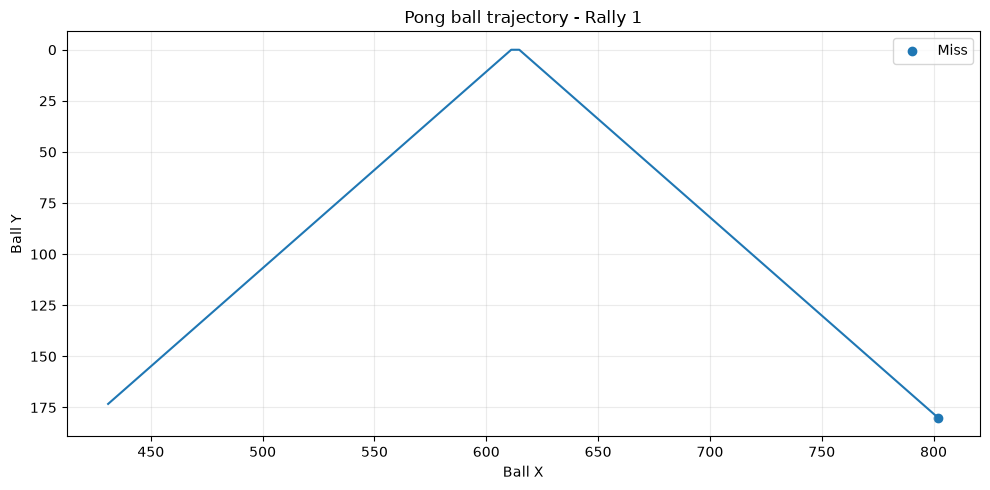

C:\Users\Abhishek\AppData\Local\Temp\ipykernel_2600\1844700676.py:99: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


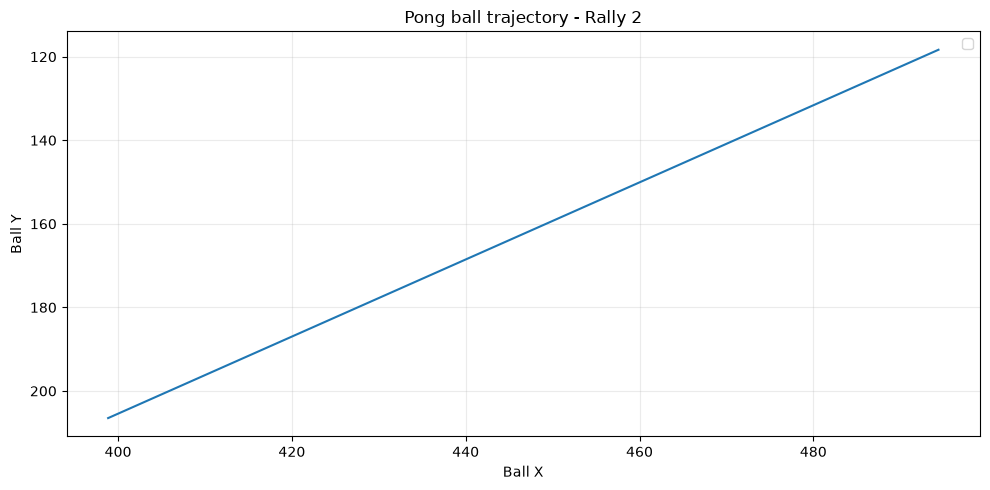

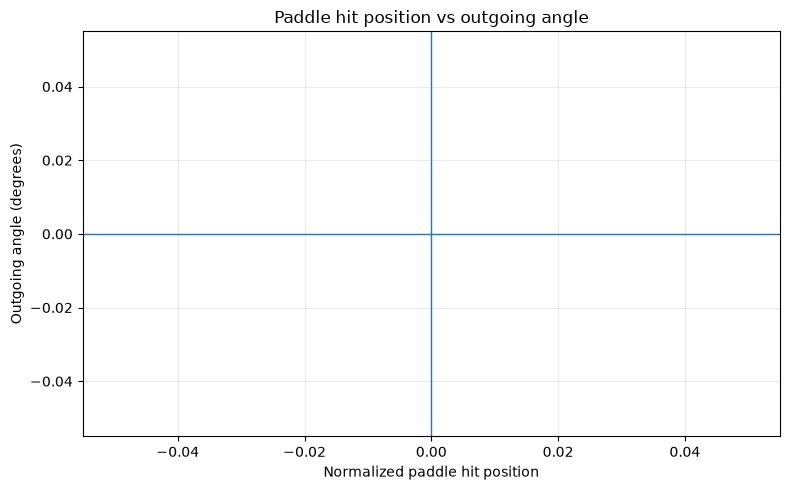

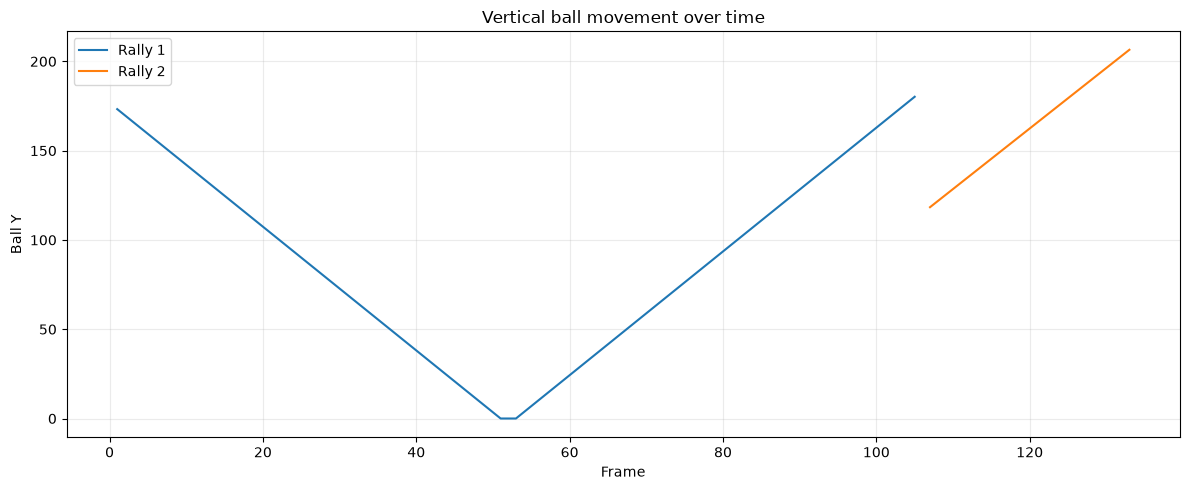

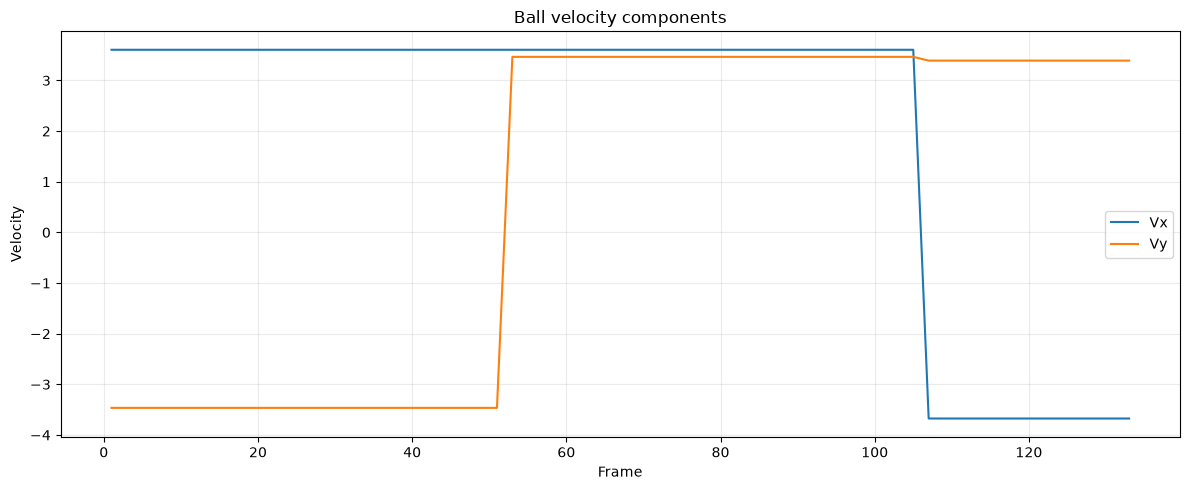

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("pong_data.csv")

# Convert numeric columns
numeric_columns = [
    "rally",
    "frame",
    "ball_x",
    "ball_y",
    "ball_vx",
    "ball_vy",
    "left_paddle_y",
    "right_paddle_y",
    "hit_position",
    "angle"
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

print("Records:", len(df))
print("Rallies:", df["rally"].nunique())

print("\nEvent counts:")
print(df["event"].value_counts())


# ==========================================
# 1. BALL TRAJECTORY FOR EACH RALLY
# ==========================================

for rally_id, rally_df in df.groupby("rally"):

    frames = rally_df[
        rally_df["event"] == "FRAME"
    ]

    if frames.empty:
        continue

    plt.figure(figsize=(10, 5))

    # Ball path
    plt.plot(
        frames["ball_x"],
        frames["ball_y"]
    )

    # Paddle hits
    hits = rally_df[
        rally_df["event"].str.contains(
            "HIT",
            na=False
        )
    ]

    if not hits.empty:
        plt.scatter(
            hits["ball_x"],
            hits["ball_y"],
            label="Paddle hit"
        )

    # Misses
    misses = rally_df[
        rally_df["event"].str.contains(
            "MISS",
            na=False
        )
    ]

    if not misses.empty:
        plt.scatter(
            misses["ball_x"],
            misses["ball_y"],
            label="Miss"
        )

    # Pygame's Y coordinate increases downward
    plt.gca().invert_yaxis()

    plt.xlabel("Ball X")
    plt.ylabel("Ball Y")

    plt.title(
        f"Pong ball trajectory - Rally {int(rally_id)}"
    )

    plt.legend()
    plt.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


# ==========================================
# 2. HIT POSITION vs OUTGOING ANGLE
# ==========================================

hits = df[
    df["event"].str.contains(
        "HIT",
        na=False
    )
].dropna(
    subset=[
        "hit_position",
        "angle"
    ]
)

plt.figure(figsize=(8, 5))

plt.scatter(
    hits["hit_position"],
    hits["angle"]
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel(
    "Normalized paddle hit position"
)

plt.ylabel(
    "Outgoing angle (degrees)"
)

plt.title(
    "Paddle hit position vs outgoing angle"
)

plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


# ==========================================
# 3. VERTICAL BALL MOVEMENT
# ==========================================

frames = df[
    df["event"] == "FRAME"
]

plt.figure(figsize=(12, 5))

for rally_id, rally_df in frames.groupby("rally"):

    plt.plot(
        rally_df["frame"],
        rally_df["ball_y"],
        label=f"Rally {int(rally_id)}"
    )

plt.xlabel("Frame")
plt.ylabel("Ball Y")

plt.title(
    "Vertical ball movement over time"
)

plt.legend()

plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


# ==========================================
# 4. BALL VELOCITY
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(
    frames["frame"],
    frames["ball_vx"],
    label="Vx"
)

plt.plot(
    frames["frame"],
    frames["ball_vy"],
    label="Vy"
)

plt.xlabel("Frame")
plt.ylabel("Velocity")

plt.title(
    "Ball velocity components"
)

plt.legend()

plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [21]:
def geometric_paddle_controller(
    paddle_y,
    ball_x,
    ball_y,
    ball_vx,
    ball_vy,
    target_x
):
    """
    Geometric AI controller.

    Predicts where the ball will arrive
    and moves the paddle toward that point.
    """

    # Only predict when the ball is moving
    # toward this paddle.
    if (
        (target_x > ball_x and ball_vx > 0)
        or
        (target_x < ball_x and ball_vx < 0)
    ):

        predicted_y = predict_ball_y_general(
            ball_x,
            ball_y,
            ball_vx,
            ball_vy,
            target_x
        )

        if predicted_y is not None:

            target_center = (
                predicted_y
                + BALL_SIZE / 2
            )

            return move_paddle_to_target(
                paddle_y,
                target_center,
                PADDLE_SPEED,
                tolerance=10
            )

    # Ball moving away → return toward center
    paddle_center = (
        paddle_y
        + PADDLE_HEIGHT / 2
    )

    screen_center = HEIGHT / 2

    return move_paddle_to_target(
        paddle_y,
        screen_center,
        PADDLE_SPEED,
        tolerance=10
    )

In [22]:
def run_ai_vs_ai():

    pygame.init()

    screen = pygame.display.set_mode(
        (WIDTH, HEIGHT)
    )

    pygame.display.set_caption(
        "Pong - Geometric AI vs Geometric AI"
    )

    clock = pygame.time.Clock()

    # =================================
    # Paddle positions
    # =================================

    left_x = 30
    right_x = WIDTH - 45

    left_y = (
        HEIGHT - PADDLE_HEIGHT
    ) / 2

    right_y = (
        HEIGHT - PADDLE_HEIGHT
    ) / 2

    # =================================
    # Collision targets
    # =================================

    left_target_x = (
        left_x + PADDLE_WIDTH
    )

    right_target_x = (
        right_x - BALL_SIZE
    )

    # =================================
    # Ball
    # =================================

    ball_x, ball_y, ball_vx, ball_vy = (
        reset_ball(
            direction=random.choice([-1, 1])
        )
    )

    # =================================
    # Score
    # =================================

    left_score = 0
    right_score = 0

    running = True

    while running:

        # =================================
        # EVENTS
        # =================================

        for event in pygame.event.get():

            if event.type == pygame.QUIT:
                running = False

        # =================================
        # LEFT AI
        # =================================

        left_y = geometric_paddle_controller(
            paddle_y=left_y,
            ball_x=ball_x,
            ball_y=ball_y,
            ball_vx=ball_vx,
            ball_vy=ball_vy,
            target_x=left_target_x
        )

        # =================================
        # RIGHT AI
        # =================================

        right_y = geometric_paddle_controller(
            paddle_y=right_y,
            ball_x=ball_x,
            ball_y=ball_y,
            ball_vx=ball_vx,
            ball_vy=ball_vy,
            target_x=right_target_x
        )

        # =================================
        # MOVE BALL
        # =================================

        ball_x += ball_vx
        ball_y += ball_vy

        # =================================
        # TOP / BOTTOM WALL
        # =================================

        if (
            ball_y <= 0
            or ball_y >= HEIGHT - BALL_SIZE
        ):

            ball_vy *= -1

            ball_y = max(
                0,
                min(
                    HEIGHT - BALL_SIZE,
                    ball_y
                )
            )

        # =================================
        # LEFT PADDLE COLLISION
        # =================================

        if (
            ball_x <= left_target_x
            and ball_vx < 0
            and left_y - BALL_SIZE
            <= ball_y
            <= left_y + PADDLE_HEIGHT
        ):

            paddle_center = (
                left_y
                + PADDLE_HEIGHT / 2
            )

            ball_center = (
                ball_y
                + BALL_SIZE / 2
            )

            relative_hit = (
                ball_center
                - paddle_center
            ) / (
                PADDLE_HEIGHT / 2
            )

            relative_hit = max(
                -1,
                min(
                    1,
                    relative_hit
                )
            )

            max_angle = math.radians(60)

            angle = (
                relative_hit
                * max_angle
            )

            ball_vx = (
                BALL_SPEED
                * math.cos(angle)
            )

            ball_vy = (
                BALL_SPEED
                * math.sin(angle)
            )

            ball_x = left_target_x

        # =================================
        # RIGHT PADDLE COLLISION
        # =================================

        if (
            ball_x + BALL_SIZE >= right_x
            and ball_vx > 0
            and right_y - BALL_SIZE
            <= ball_y
            <= right_y + PADDLE_HEIGHT
        ):

            paddle_center = (
                right_y
                + PADDLE_HEIGHT / 2
            )

            ball_center = (
                ball_y
                + BALL_SIZE / 2
            )

            relative_hit = (
                ball_center
                - paddle_center
            ) / (
                PADDLE_HEIGHT / 2
            )

            relative_hit = max(
                -1,
                min(
                    1,
                    relative_hit
                )
            )

            max_angle = math.radians(60)

            angle = (
                relative_hit
                * max_angle
            )

            ball_vx = -(
                BALL_SPEED
                * math.cos(angle)
            )

            ball_vy = (
                BALL_SPEED
                * math.sin(angle)
            )

            ball_x = (
                right_x
                - BALL_SIZE
            )

        # =================================
        # RIGHT MISS
        # =================================

        if ball_x > WIDTH:

            left_score += 1

            print(
                "LEFT AI SCORES |",
                left_score,
                "-",
                right_score
            )

            ball_x, ball_y, ball_vx, ball_vy = (
                reset_ball(
                    direction=-1
                )
            )

        # =================================
        # LEFT MISS
        # =================================

        if ball_x < -BALL_SIZE:

            right_score += 1

            print(
                "RIGHT AI SCORES |",
                left_score,
                "-",
                right_score
            )

            ball_x, ball_y, ball_vx, ball_vy = (
                reset_ball(
                    direction=1
                )
            )

        # =================================
        # DRAW - GLASSMORPHIC THEME
        # =================================

        draw_themed_scene(
            screen,
            ball_x,
            ball_y,
            left_x,
            left_y,
            right_x,
            right_y,
            left_score,
            right_score
        )

        pygame.display.flip()

        clock.tick(FPS)

    # =================================
    # CLEANUP
    # =================================

    pygame.quit()

    print()
    print("AI vs AI finished")
    print("Left AI score:", left_score)
    print("Right AI score:", right_score)

In [ ]:
run_ai_vs_ai()

In [ ]:
predict_ball_y(
    ball_x=400,
    ball_y=250,
    ball_vx=5,
    ball_vy=0,
    target_x=750
)

In [ ]:
predict_ball_y(
    ball_x=400,
    ball_y=250,
    ball_vx=5,
    ball_vy=2,
    target_x=750
)

In [ ]:
predict_ball_y(
    ball_x=400,
    ball_y=400,
    ball_vx=5,
    ball_vy=4,
    target_x=750
)

In [ ]:
RIGHT_PADDLE_X = WIDTH - 30
RIGHT_TARGET_X = RIGHT_PADDLE_X - BALL_SIZE

print("Right paddle X:", RIGHT_PADDLE_X)
print("Ball target X:", RIGHT_TARGET_X)

In [ ]:
predict_ball_y(
    ball_x=400,
    ball_y=250,
    ball_vx=5,
    ball_vy=2,
    target_x=RIGHT_TARGET_X
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# IMPORTANT:
# Use the large dataset, not the old pong_data_clean.csv
df = pd.read_csv("pong_data.xls")

print("Dataset shape:", df.shape)
print()
print(df["event"].value_counts())

# --------------------------------------------------
# Find the actual right-paddle collision X
# --------------------------------------------------

right_hits = df.loc[
    df["event"] == "RIGHT_HIT",
    "ball_x"
]

RIGHT_TARGET_X = right_hits.median()

print()
print("Right paddle collision X:", RIGHT_TARGET_X)


# --------------------------------------------------
# Find actual Y when ball reaches right paddle
# --------------------------------------------------

def get_actual_right_impact(segment):

    # If the paddle actually hit the ball,
    # we have an exact recorded collision.
    hit_rows = segment[
        segment["event"] == "RIGHT_HIT"
    ]

    if len(hit_rows) > 0:
        return hit_rows.iloc[0]["ball_y"]

    # Otherwise the ball missed the paddle.
    # Find where it crossed the paddle's X.
    crossed = segment[
        segment["ball_x"] >= RIGHT_TARGET_X
    ]

    if len(crossed) == 0:
        return None

    current = crossed.iloc[0]

    previous_rows = segment[
        segment["frame"] < current["frame"]
    ]

    if len(previous_rows) == 0:
        return current["ball_y"]

    previous = previous_rows.iloc[-1]

    dx = (
        current["ball_x"]
        - previous["ball_x"]
    )

    if dx == 0:
        return current["ball_y"]

    # Interpolate between the two frames
    ratio = (
        RIGHT_TARGET_X
        - previous["ball_x"]
    ) / dx

    actual_y = (
        previous["ball_y"]
        + ratio * (
            current["ball_y"]
            - previous["ball_y"]
        )
    )

    return actual_y


# --------------------------------------------------
# Continuous prediction validation
# --------------------------------------------------

results = []

for rally_id, rally in df.groupby("rally"):

    rally = (
        rally
        .sort_values("frame")
        .reset_index(drop=True)
    )

    left_hits = rally[
        rally["event"] == "LEFT_HIT"
    ]

    for _, left_hit in left_hits.iterrows():

        start_frame = left_hit["frame"]

        # Ball trajectory after LEFT_HIT
        segment = rally[
            rally["frame"] >= start_frame
        ].copy()

        # Find the next right-side outcome
        right_outcomes = segment[
            segment["event"].isin([
                "RIGHT_HIT",
                "MISS_RIGHT"
            ])
        ]

        if len(right_outcomes) == 0:
            continue

        outcome_frame = (
            right_outcomes.iloc[0]["frame"]
        )

        segment = segment[
            segment["frame"] <= outcome_frame
        ]

        # Actual Y at the right paddle
        actual_y = get_actual_right_impact(segment)

        if actual_y is None:
            continue

        # Every frame where the ball is moving
        # toward the right paddle
        prediction_frames = segment[
            (segment["ball_vx"] > 0) &
            (segment["ball_x"] < RIGHT_TARGET_X)
        ]

        for _, row in prediction_frames.iterrows():

            predicted_y = predict_ball_y(
                ball_x=row["ball_x"],
                ball_y=row["ball_y"],
                ball_vx=row["ball_vx"],
                ball_vy=row["ball_vy"],
                target_x=RIGHT_TARGET_X
            )

            if predicted_y is None:
                continue

            distance = (
                RIGHT_TARGET_X
                - row["ball_x"]
            )

            error = abs(
                predicted_y - actual_y
            )

            results.append({
                "rally": rally_id,
                "frame": row["frame"],
                "ball_x": row["ball_x"],
                "distance": distance,
                "predicted_y": predicted_y,
                "actual_y": actual_y,
                "error": error
            })


# --------------------------------------------------
# Create results DataFrame
# --------------------------------------------------

results_df = pd.DataFrame(results)

print()
print("Continuous predictions:", len(results_df))

if len(results_df) > 0:

    print(
        "Rallies tested:",
        results_df["rally"].nunique()
    )

    print()
    print(
        "Mean error:",
        round(results_df["error"].mean(), 3),
        "pixels"
    )

    print(
        "Median error:",
        round(results_df["error"].median(), 3),
        "pixels"
    )

    print(
        "Maximum error:",
        round(results_df["error"].max(), 3),
        "pixels"
    )

else:

    print()
    print("WARNING: No predictions were generated.")

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    results_df["distance"],
    results_df["error"],
    alpha=0.35
)

plt.xlabel("Distance from right paddle (pixels)")
plt.ylabel("Prediction error (pixels)")
plt.title("Prediction Error vs Distance from Paddle")

plt.gca().invert_xaxis()

plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    results_df["actual_y"],
    results_df["predicted_y"],
    alpha=0.35
)

# Perfect prediction line
plt.plot(
    [0, HEIGHT],
    [0, HEIGHT]
)

plt.xlabel("Actual impact Y")
plt.ylabel("Predicted impact Y")
plt.title("Predicted vs Actual Paddle Impact")

plt.grid(True, alpha=0.3)

plt.show()